# Generación de paleta de colores a partir de imágenes con técnicas de machine learning no supervisado.

El problema central radica en desarrollar un método automatizado que pueda generar una paleta coherente y estéticamente atractiva partiendo de los colores identificados en una imagen. Esto implica no solo reconocer tonos dominantes, sino también comprender la relación existente al interior de la gama cromática empleada para crear combinaciones visuales agradables y funcionales. Abordar este problema se traduciría en varias ventajas:

Eficiencia en el proceso creativo, al liberar tiempo que los autores podrían emplear en otros aspectos estratégicos de sus proyectos.

Consistencia interna en los diseños, manteniendo una identidad visual constante en diferentes aplicaciones y proyectos.

Facilidad de uso y recurso de aprendizaje para personas con menos experiencia en diseño, fomentando la creatividad en diversos campos.

Optimización de la calidad y del impacto de la comunicación visual. 

A. Objetivo.

Desarrollar un método, basado en técnicas de agrupación, que permita extraer los tonos dominantes de una imagen y generar un muestrario de los colores representativos presentes en esta. 

B. Conjunto de datos. 

Los datos están asociados con imágenes de obras de arte. Pueden ser descargados a partir de este
 enlace
.

C. Actividades para realizar.

1. Recopilación de las imágenes a partir del repositorio. La idea es seleccionar un conjunto diverso de muestras en diferentes estilos artísticos (varios pintores). Se recomienda seleccionar entre 6 y 10 imágenes.

2. Preparación de las imágenes para el entrenamiento y prueba del modelo. Para este paso construir un pipeline que integre las transformaciones que se consideren adecuadas.

3. Desarrollo del modelo de agrupación para identificar los colores dominantes en una imagen.

4. Transformación de los grupos de colores identificados en un muestrario representativo. Adicionalmente, se debería mostrar la distribución de los colores de la imagen en un espacio de dos dimensiones utilizando una técnica de reducción de la dimensionalidad.

D. Consideraciones.
<!--  -->
Un diagrama general del método que se quiere desarrollar se muestra en la siguiente la Fig. 1

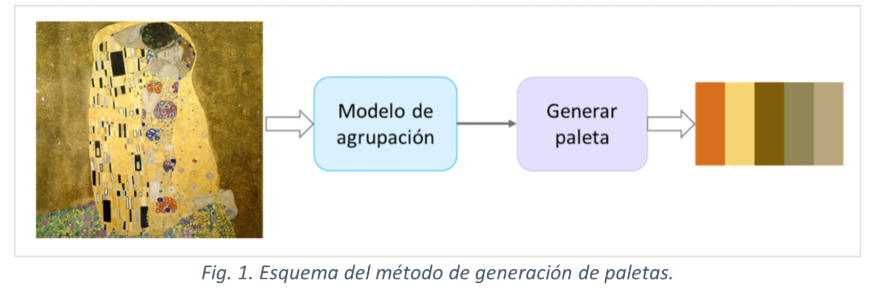

## 1. Importacion de Librerias a utilzar


In [14]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth

## 2. Funciones reutilizables:

Consideramos propicio en definir una serie de funciones para poder usarlas facilmente en los diferentes procesos de proyecto para mas comodidad y orden.

Las funciones que creamos son las siguientes:
- `load_images()`: Esta función nos sirve para el cargue de todas las imágenes y al mismo tiempo preprocesarlas para convertirlas a canalas RGB, aplanarlas y aplicar una normalización en el rango de 0 a 1 para que a los algoritmos de agrupación se les facilité la tarea.
- `train_models()`: Esta función la creamos para realizar el entrenamiento automatizado de cada unas de las imágenes, entrenando un modelo de agrupación de manera independiente por cada una de las imágenes y al mismo tiempo guardamos en varias `listas` los siguentes datos:
    -  `lista_img_segmented[]`: Guardamos la imágen final segmentada por el algorítmo y poder comparar las imágenes originales más fácilmente. 
    -  `list_centroids[]`: Guardamos todos los centroides de cada grupo los cuales corresponderían a los colores de cada grupo generado por el algorítmo.

In [15]:
def load_images(root_path, file_names, flatten=True, normalize=True):
    """
    Retorna una lista con arreglos de números. Cada arreglo representa una imagen RGB.
    
    Parametros:
    root_path : str
        Directorio raíz de las imágenes.
    file_names : list
        Lista con los nombres de los archivos de imágenes.
    flatten : bool, opcional
        Si es True, aplana las imágenes a una lista de píxeles de tres dimensiones.
    normalize : bool, opcional
        Si es True, normaliza los valores de píxeles al rango [0, 1].
    """
    image_list = list()
    for file in file_names:
        img = cv2.imread(os.path.join(root_path, file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if flatten:
            img = img.reshape((-1, 3))
        if normalize:
            img = img / 255.0
        image_list.append(img)
    return image_list

def train_models(num_clusters = 5, model=None, n_init=10):
    
    lista_img_segmented = []
    list_centroids = []
    list_paletas = []
    inertias = []
    
    for img_c, img_ori in zip(imagenes_convertidas, imagenes_originales):

        if model == "kmeans":

            model_entrenado = KMeans(n_clusters=num_clusters, max_iter=300, n_init=n_init, random_state=143)
            model_entrenado.fit(img_c)
            inertias.append(model_entrenado.inertia_)
            labels = model_entrenado.labels_

            paleta_img = dict(zip(*np.unique(labels, return_counts=True)))
            list_paletas.append(paleta_img) 

            centroids = model_entrenado.cluster_centers_
            list_centroids.append((centroids*255).astype(np.uint8).reshape(1, -1, 3))
            img_segmented = centroids[labels]*255
            img_segmented = img_segmented.reshape(img_ori.shape)
            lista_img_segmented.append(img_segmented)

        if model == "DBSCAN":
            print("aun no implemendado")
    return lista_img_segmented,list_centroids,list_paletas, inertias





## 3.  Cargue de imagenes:

In [16]:
#Creacion de nuestra lista de nombres de las imagenes que escogimos

lista_nombres_imagenes = os.listdir("data")
lista_nombres_imagenes


['a.y.-jackson_maple-woods-algoma-1920.jpg',
 'aaron-siskind_westport-10-1988.jpg',
 'adolf-hitler_alter-werderthor-wien.jpg',
 'albert-bloch_summer-night-1913.jpg',
 'aldo-mondino_silveti-1995.jpg',
 'donald-sultan_apples-and-oranges-1987.jpg',
 'franz-kline_mycenae-1958.jpg',
 'georges-braque_still-life-with-ace-of-hearts-1914.jpg',
 'georges-braque_the-city-on-the-hill-1909.jpg',
 'hiroshige_eagle-over-100-000-acre-plain-at-susaki-fukagawa-juman-tsubo.jpg']

In [17]:
imagenes_originales = load_images("data",lista_nombres_imagenes,False,False)
imagenes_originales

[array([[[169,  96,  41],
         [169,  96,  41],
         [171,  96,  41],
         ...,
         [173, 135,  99],
         [171, 135,  99],
         [171, 135,  99]],
 
        [[171,  98,  43],
         [171,  98,  43],
         [173,  98,  43],
         ...,
         [183, 140, 105],
         [181, 141, 105],
         [181, 141, 106]],
 
        [[172, 102,  43],
         [173, 103,  44],
         [174, 102,  44],
         ...,
         [190, 140, 105],
         [190, 140, 105],
         [190, 140, 107]],
 
        ...,
 
        [[208, 136,  51],
         [215, 143,  58],
         [218, 141,  59],
         ...,
         [165, 126,  69],
         [165, 126,  69],
         [166, 125,  69]],
 
        [[209, 137,  52],
         [216, 144,  59],
         [221, 144,  62],
         ...,
         [159, 123,  65],
         [159, 123,  65],
         [161, 122,  65]],
 
        [[210, 138,  53],
         [217, 145,  60],
         [223, 146,  64],
         ...,
         [159, 123,  65],
  

In [18]:

##for img_ori in zip(imagenes_originales):
    ##plt.figure(figsize=(10, 5))

    ##plt.subplot(1)
    ##plt.title('Imagen Original')
    ##plt.imshow(img_ori)
    ##plt.axis('off')

    ##plt.tight_layout()
    ##plt.show()

In [19]:
imagenes_convertidas = load_images("data",lista_nombres_imagenes) #no le colocamos el true true ya que por defecto esos son los valores de la función load_images
imagenes_convertidas

[array([[0.6627451 , 0.37647059, 0.16078431],
        [0.6627451 , 0.37647059, 0.16078431],
        [0.67058824, 0.37647059, 0.16078431],
        ...,
        [0.62352941, 0.48235294, 0.25490196],
        [0.62352941, 0.48235294, 0.25490196],
        [0.62352941, 0.48235294, 0.25490196]], shape=(2458578, 3)),
 array([[0.95686275, 0.83921569, 0.83921569],
        [0.91764706, 0.81568627, 0.81176471],
        [0.85490196, 0.77254902, 0.76078431],
        ...,
        [0.83137255, 0.79607843, 0.76078431],
        [0.82352941, 0.78431373, 0.74901961],
        [0.80392157, 0.74509804, 0.71764706]], shape=(1933418, 3)),
 array([[0.65098039, 0.5372549 , 0.41960784],
        [0.65098039, 0.5372549 , 0.41960784],
        [0.65490196, 0.54117647, 0.42352941],
        ...,
        [0.69019608, 0.57647059, 0.45882353],
        [0.69803922, 0.58431373, 0.46666667],
        [0.70196078, 0.58823529, 0.47058824]], shape=(2099258, 3)),
 array([[0.70980392, 0.76078431, 0.89411765],
        [0.75686275, 

In [20]:
print(f'Shape Imagenes Originales: {imagenes_originales[8].shape}')
print(f'Shape Imagenes convertidas: {imagenes_convertidas[8].shape}')


Shape Imagenes Originales: (1724, 1382, 3)
Shape Imagenes convertidas: (2382568, 3)


<div style="
background:#d3f9d8;
border-left:6px solid #27b91a;
padding:16px;
border-radius:8px;
margin:12px 0;
width:1000px;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Justificaciones</b><br>
No es necesario redimencionar las imagenes a un mismo tamaño ya que la tarea que queremos realizar es por cada una de las imanges, aplicando un algoritmo de agrupación por imagen para generar la paleta de colores de cada una de ellas.

</div>

## 3. Entrenamiento de algoritmos:

In [21]:
lista_img_segmented,list_centroids,list_paletas, lista_inertias = train_models(num_clusters=7,model="kmeans")


In [22]:
list_centroids

[array([[[ 78,  40,  18],
         [195,  95,  22],
         [214, 171, 103],
         [168, 116,  50],
         [176,  62,  16],
         [216, 131,  36],
         [128,  74,  29]]], dtype=uint8),
 array([[[ 72,  68,  61],
         [220, 219, 211],
         [ 36,  35,  30],
         [150, 146, 138],
         [245, 245, 238],
         [111, 107,  99],
         [187, 184, 176]]], dtype=uint8),
 array([[[ 42,  35,  30],
         [172, 140, 110],
         [150, 120,  94],
         [ 83,  63,  50],
         [130, 102,  80],
         [209, 187, 160],
         [109,  84,  65]]], dtype=uint8),
 array([[[ 85,  88, 145],
         [171, 179, 227],
         [ 60,  40,  42],
         [205, 212, 245],
         [ 76,  67,  95],
         [141, 148, 201],
         [112, 117, 175]]], dtype=uint8),
 array([[[ 45,  45,  45],
         [158, 166, 175],
         [148,  90,  81],
         [212, 215, 221],
         [ 84,  74,  73],
         [112, 117, 122],
         [ 61,  59,  58]]], dtype=uint8),
 array([[[

In [23]:
df_list_paletas = pd.DataFrame(list_paletas)
df_list_paletas

,0,1,2,3,4,5,6
0,191600,703390,123194,304328,458590,355411,322065
1,151510,201850,789934,123415,402802,125419,138488
2,92405,403657,477930,213893,447020,93264,371089
3,315398,327711,224756,241384,206606,333368,322891
4,659762,53749,100136,168565,391796,65975,970225
5,570994,222248,292216,103091,201330,83296,439513
6,603449,614427,164356,486486,95139,70313,504564
7,434330,641643,239063,632646,68245,55844,464199
8,716766,150282,90735,135405,248457,548420,492503
9,281277,416638,559312,604205,445929,50359,496110


In [24]:
list_paletas

[{np.int32(0): np.int64(191600),
  np.int32(1): np.int64(703390),
  np.int32(2): np.int64(123194),
  np.int32(3): np.int64(304328),
  np.int32(4): np.int64(458590),
  np.int32(5): np.int64(355411),
  np.int32(6): np.int64(322065)},
 {np.int32(0): np.int64(151510),
  np.int32(1): np.int64(201850),
  np.int32(2): np.int64(789934),
  np.int32(3): np.int64(123415),
  np.int32(4): np.int64(402802),
  np.int32(5): np.int64(125419),
  np.int32(6): np.int64(138488)},
 {np.int32(0): np.int64(92405),
  np.int32(1): np.int64(403657),
  np.int32(2): np.int64(477930),
  np.int32(3): np.int64(213893),
  np.int32(4): np.int64(447020),
  np.int32(5): np.int64(93264),
  np.int32(6): np.int64(371089)},
 {np.int32(0): np.int64(315398),
  np.int32(1): np.int64(327711),
  np.int32(2): np.int64(224756),
  np.int32(3): np.int64(241384),
  np.int32(4): np.int64(206606),
  np.int32(5): np.int64(333368),
  np.int32(6): np.int64(322891)},
 {np.int32(0): np.int64(659762),
  np.int32(1): np.int64(53749),
  np.int3

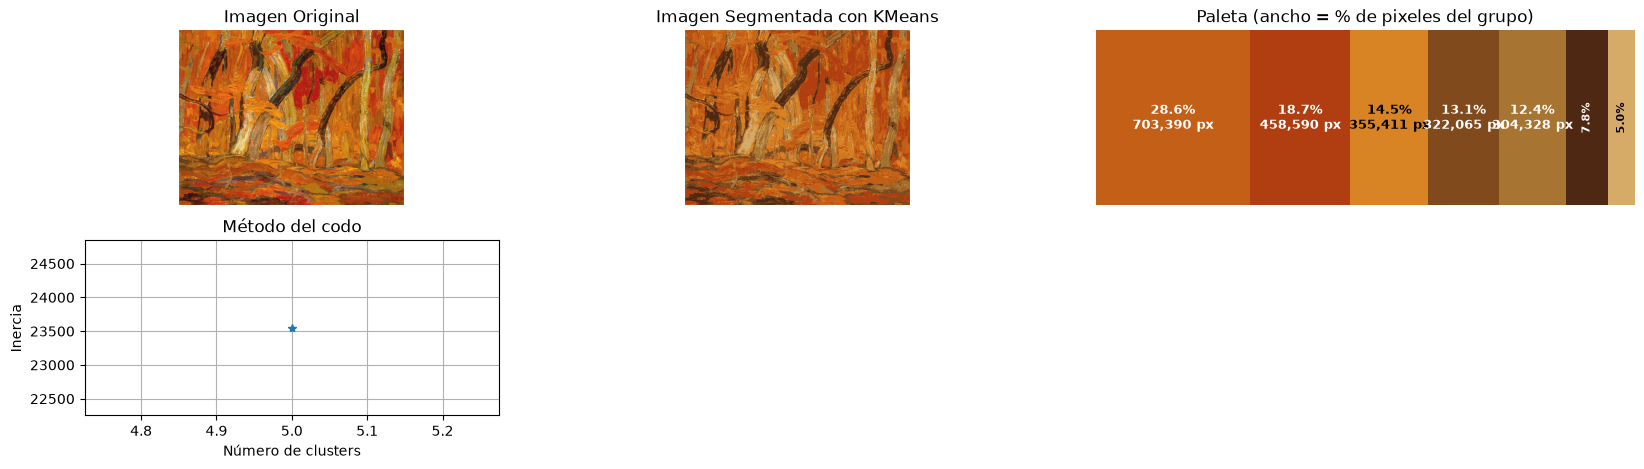

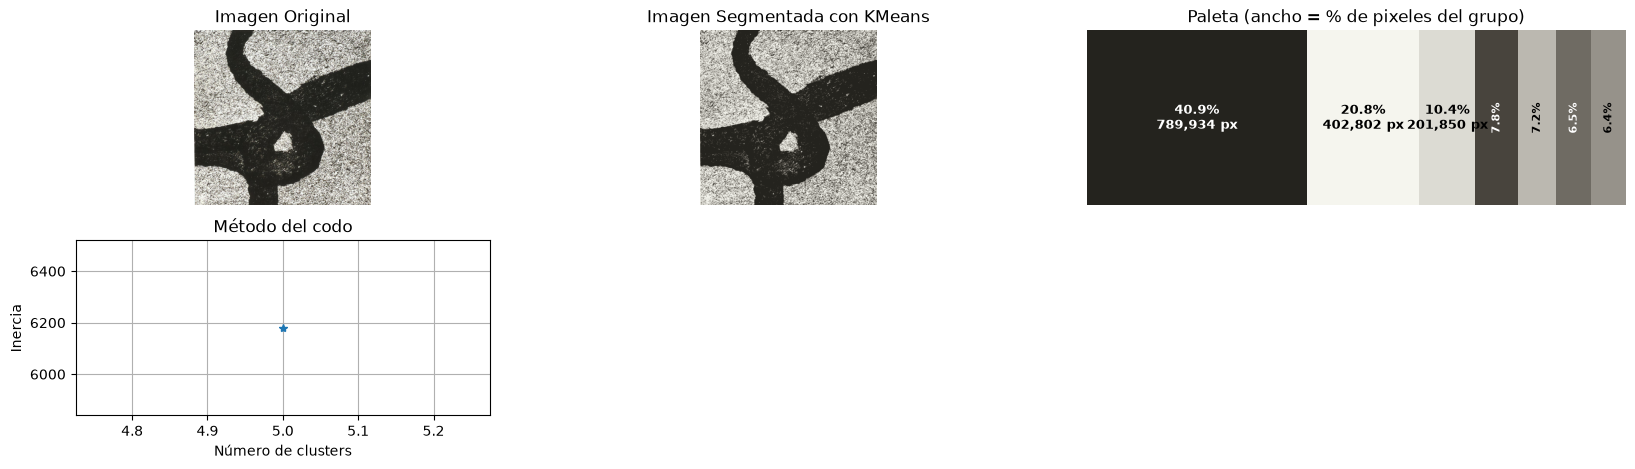

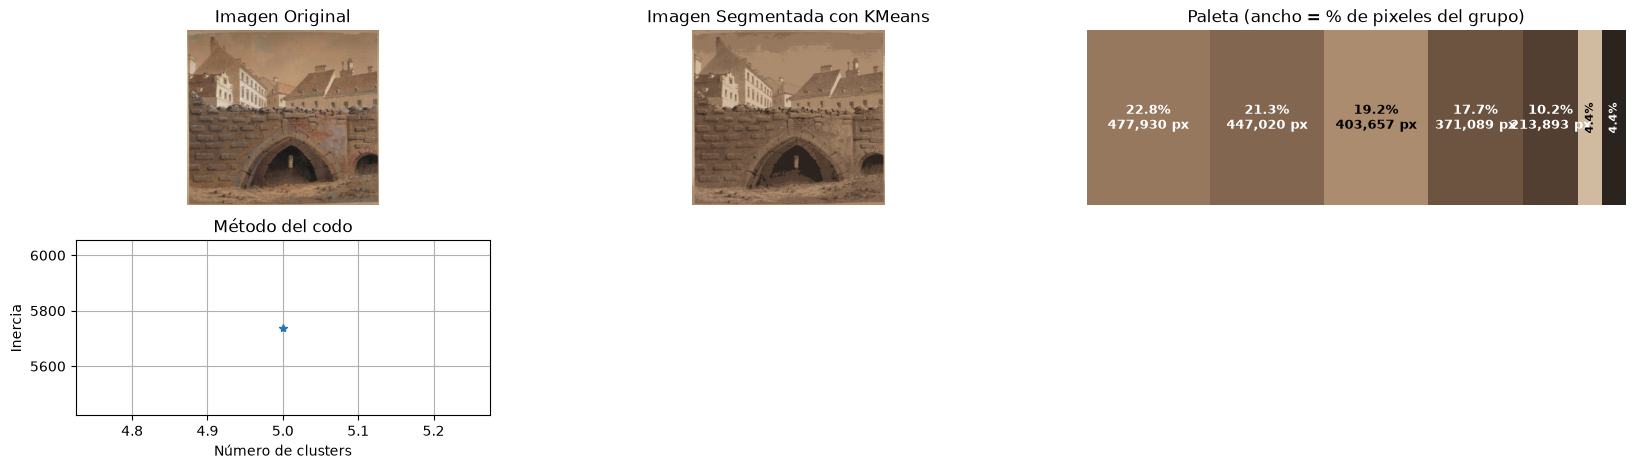

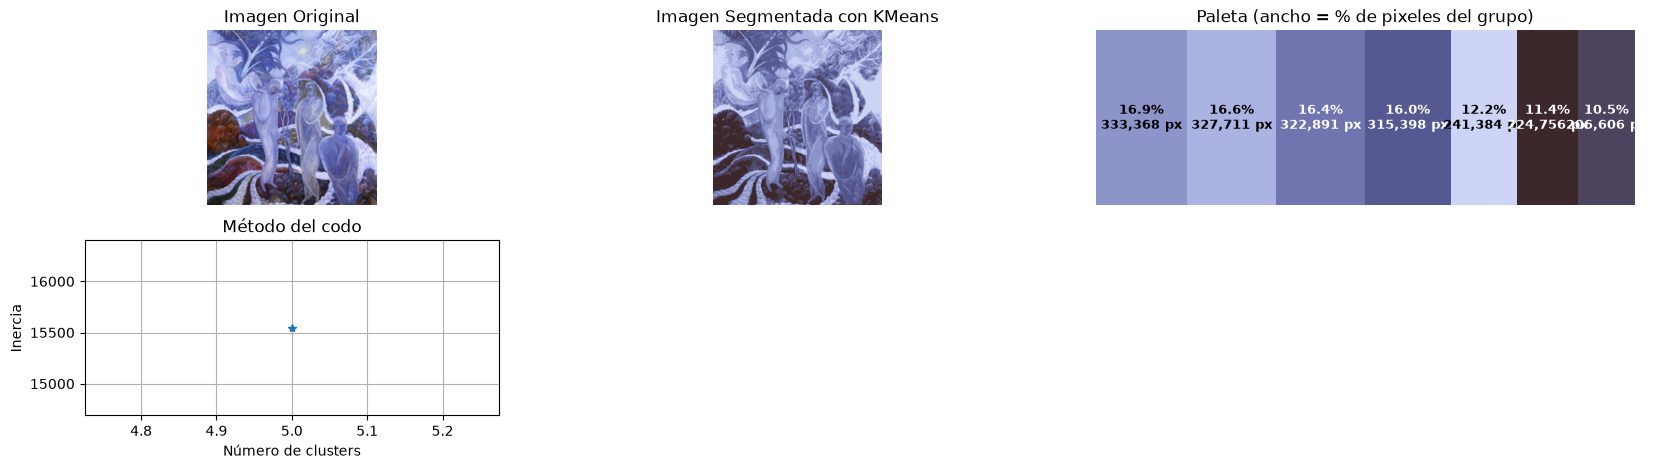

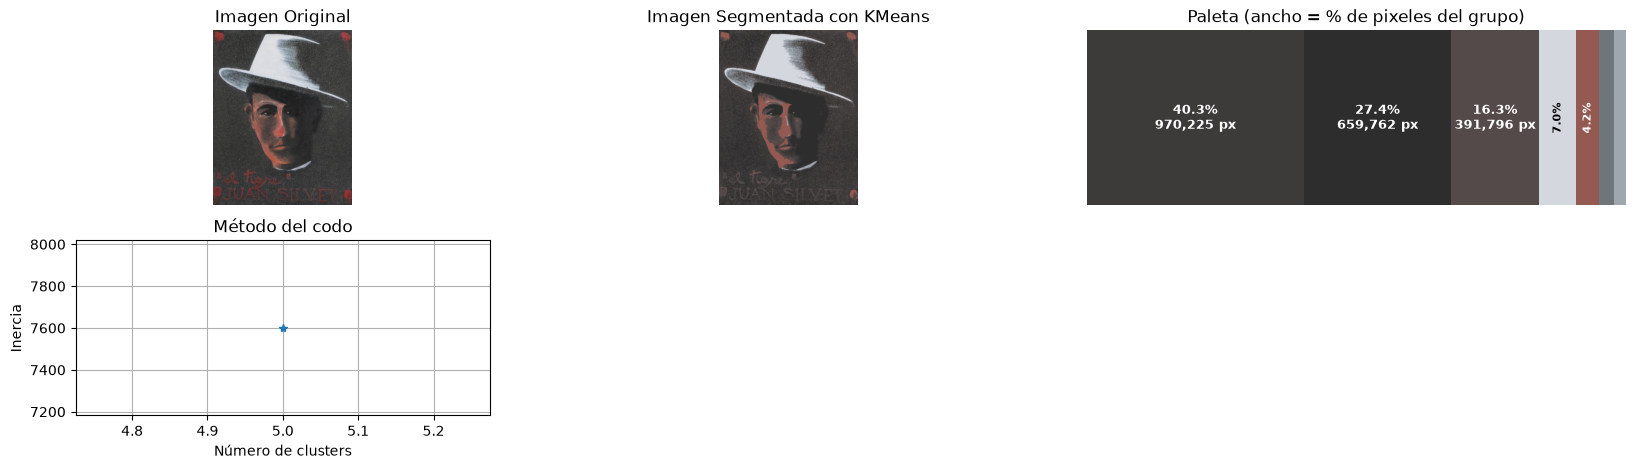

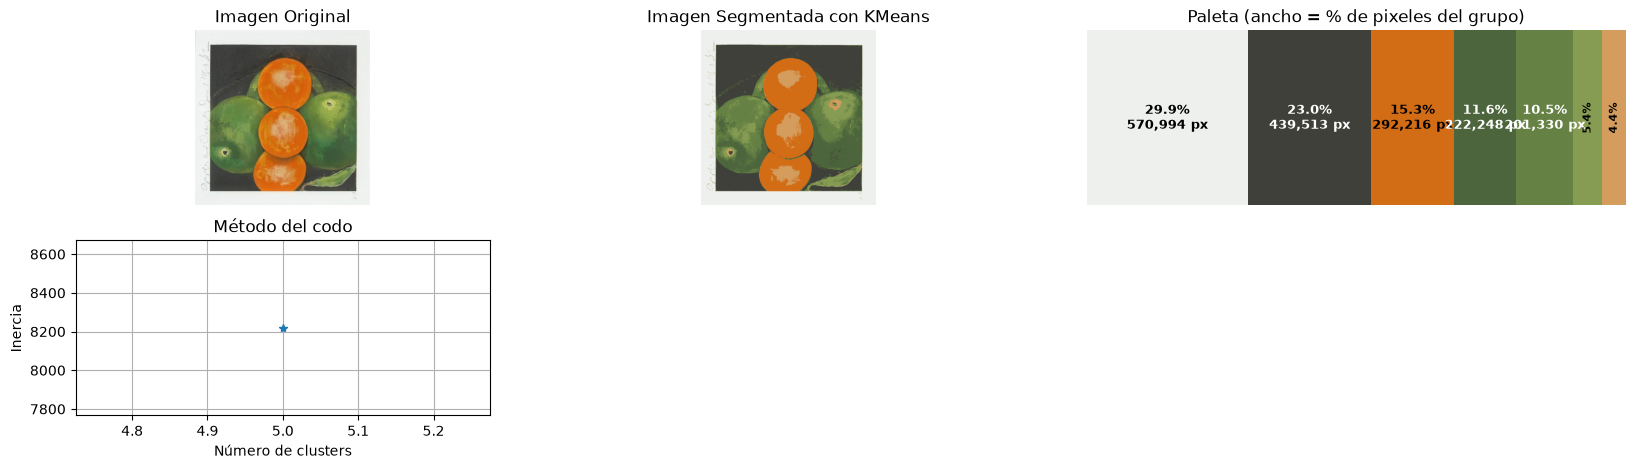

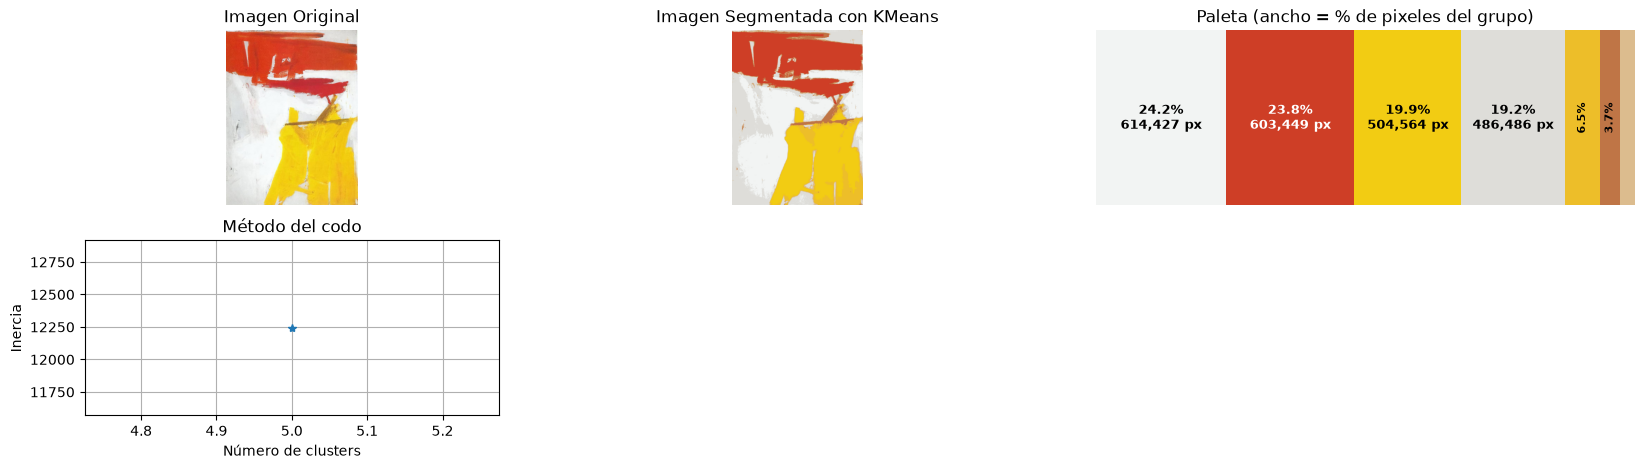

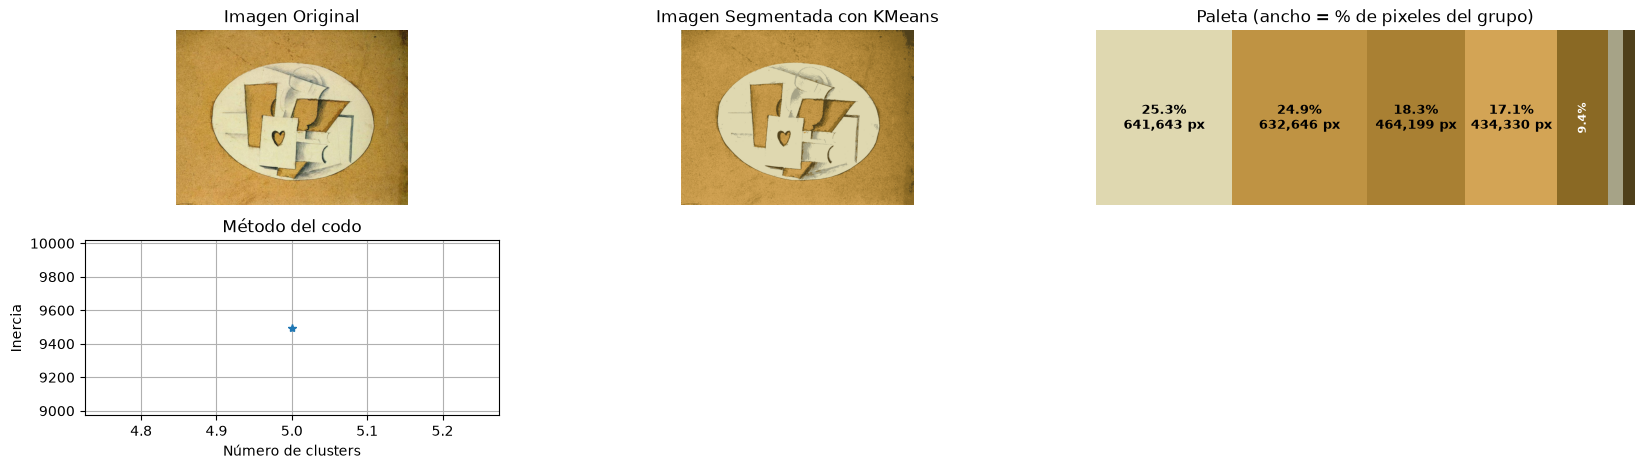

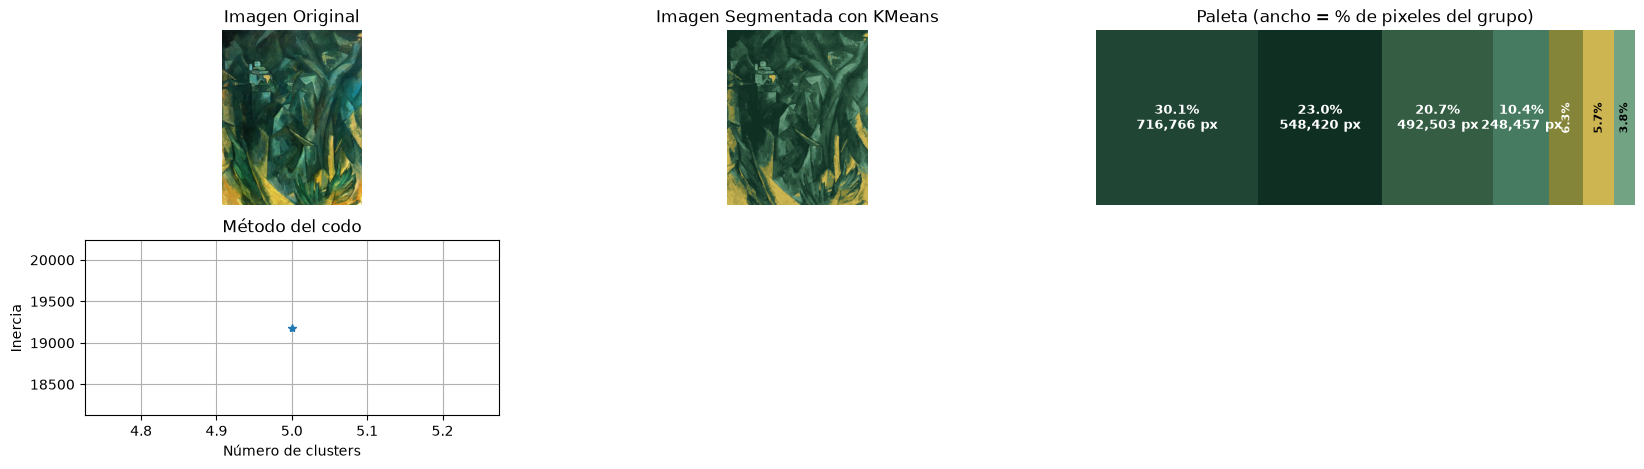

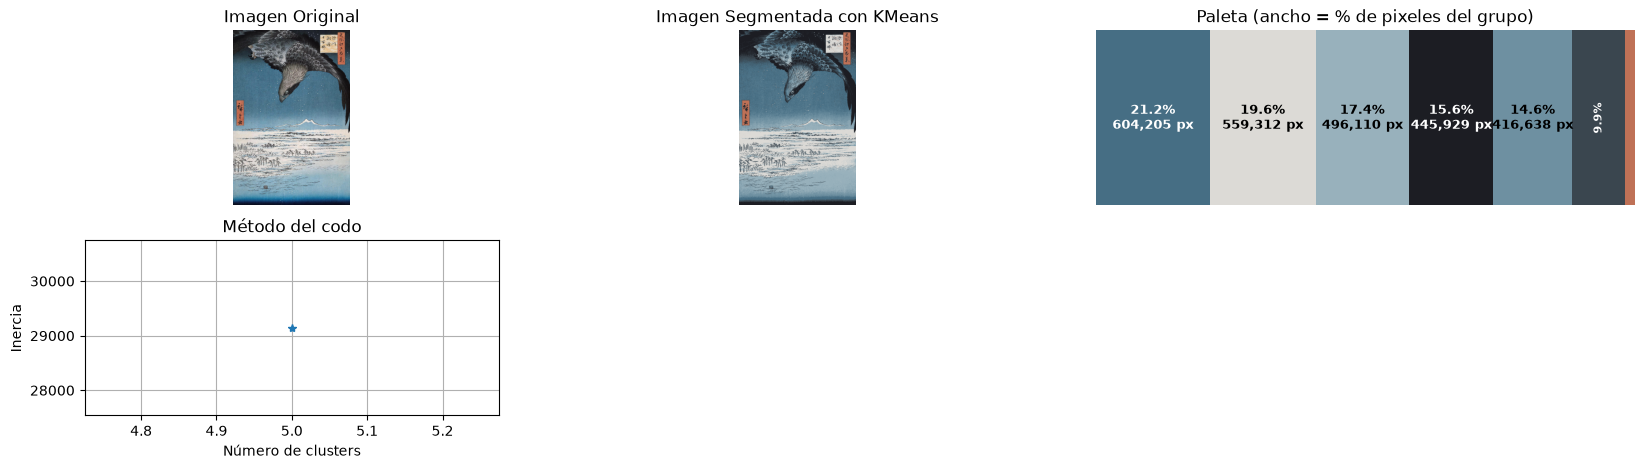

In [37]:
for img_seg, img_ori, centroi, paleta, inert in zip(lista_img_segmented, imagenes_originales, list_centroids, list_paletas, lista_inertias):

    fig, axes = plt.subplots(2, 3, figsize=(20, 5), gridspec_kw={'width_ratios': [1, 1, 1.3]})

    axes[0, 0].set_title('Imagen Original')
    axes[0, 0].imshow(img_ori)
    axes[0, 0].axis('off')

    axes[0, 1].set_title('Imagen Segmentada con KMeans')
    axes[0, 1].imshow(img_seg.astype(np.uint8))
    axes[0, 1].axis('off')

    #Paleta proporcional al numero de valores de cada grupo 
    colores = centroi.reshape(-1, 3) / 255.0           # colores (centroides) en rango [0, 1]
    etiquetas = np.array(sorted(paleta.keys()))        # etiquetas de los grupos
    conteos = np.array([paleta[e] for e in etiquetas], dtype=float)
    proporciones = conteos / conteos.sum()             # peso de cada color en la imagen

    izquierda = 0.0
    for pos in np.argsort(-proporciones):              
        ancho = proporciones[pos]
        color = colores[etiquetas[pos]]
        axes[0, 2].barh(0, ancho, left=izquierda, height=1.0, color=color)

        if ancho > 0.03:                               # solo etiquetamos las franjas visibles
            r, g, b = color
            colores_paleta = 0.299 * r + 0.587 * g + 0.114 * b
            ancha = ancho >= 0.10                      # hay espacio para el texto horizontal
            etiqueta = f'{ancho * 100:.1f}%\n{int(conteos[pos]):,} px' if ancha else f'{ancho * 100:.1f}%'
            axes[0, 2].text(izquierda + ancho / 2, 0, etiqueta,
                         ha='center', va='center', fontsize=9 if ancha else 8,
                         fontweight='bold', rotation=0 if ancha else 90,
                         color='white' if colores_paleta < 0.5 else 'black')
        izquierda += ancho

    axes[0, 2].set_title('Paleta (ancho = % de pixeles del grupo)')
    axes[0, 2].set_xlim(0, 1)
    axes[0, 2].set_ylim(-0.5, 0.5)
    axes[0, 2].axis('off')

    axes[1, 0].set_title('Método del codo')
    axes[1, 0].plot(5, inert, marker='*')
    axes[1, 0].set_xlabel('Número de clusters')
    axes[1, 0].set_ylabel('Inercia')
    axes[1, 0].grid()
    axes[1, 1].axis('off')
    axes[1, 2].axis('off')
   

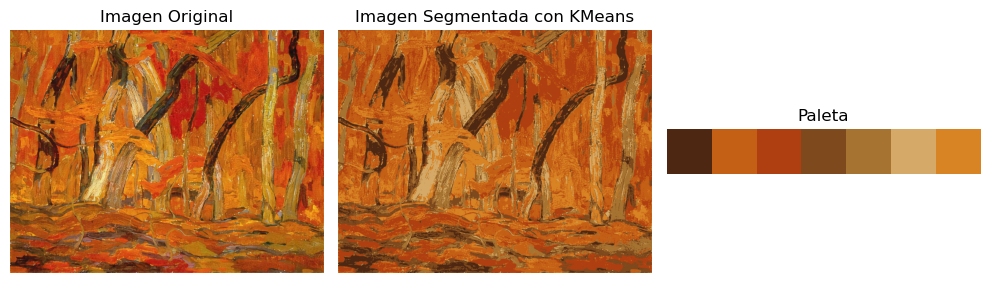

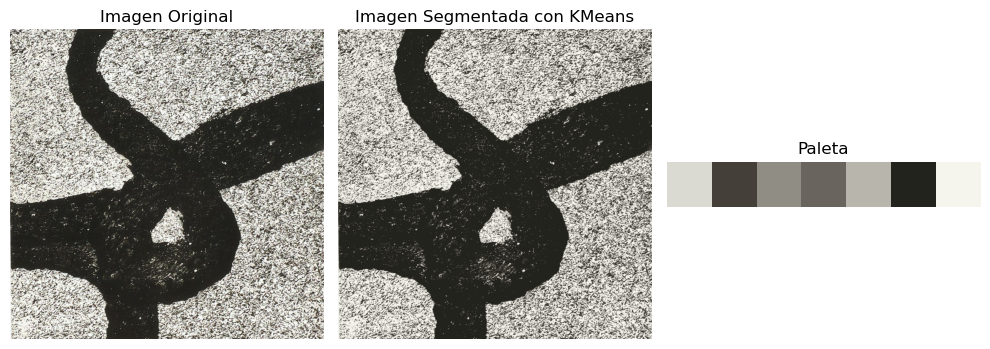

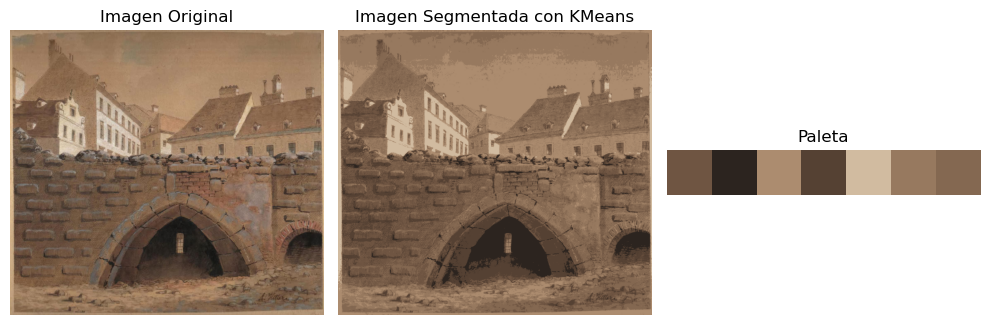

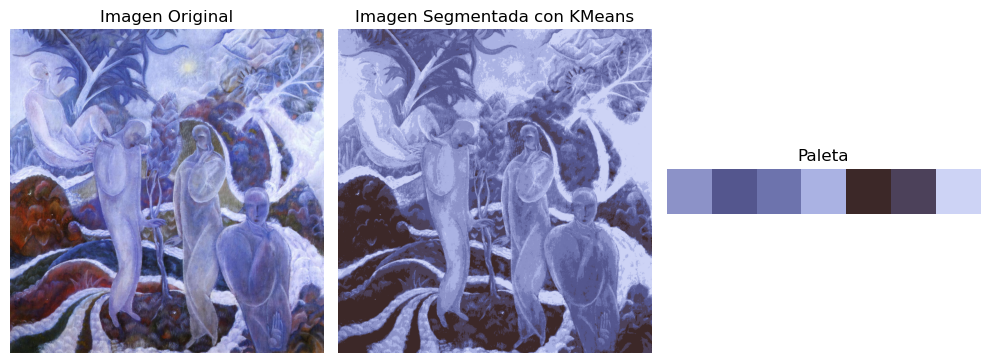

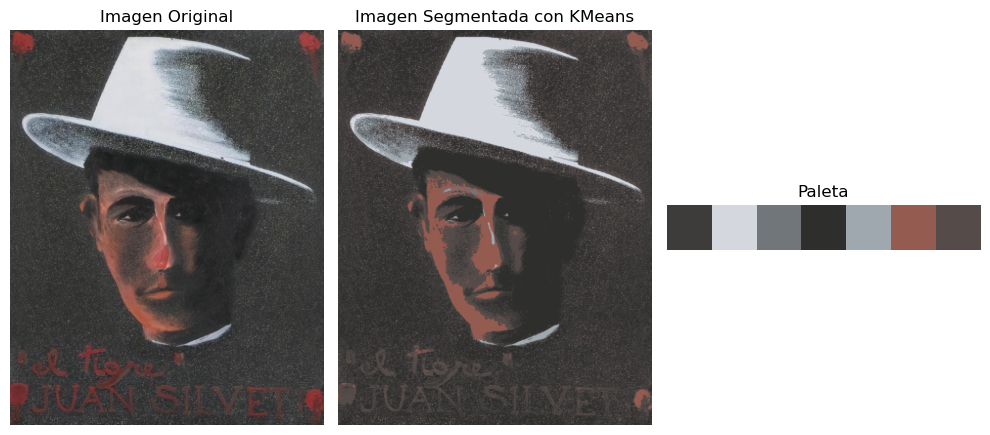

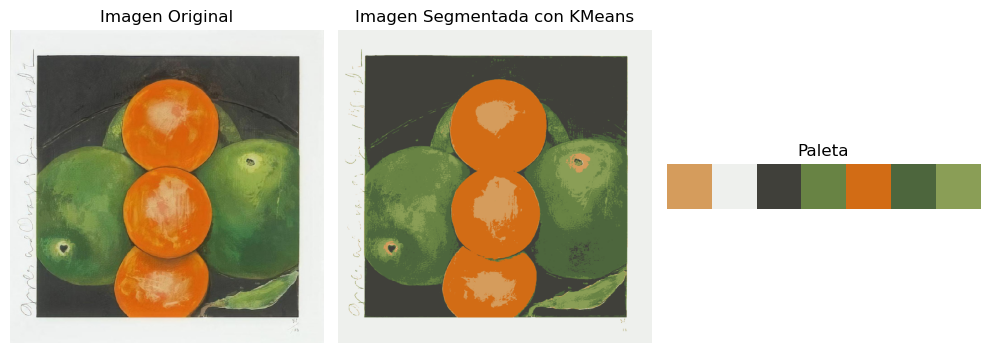

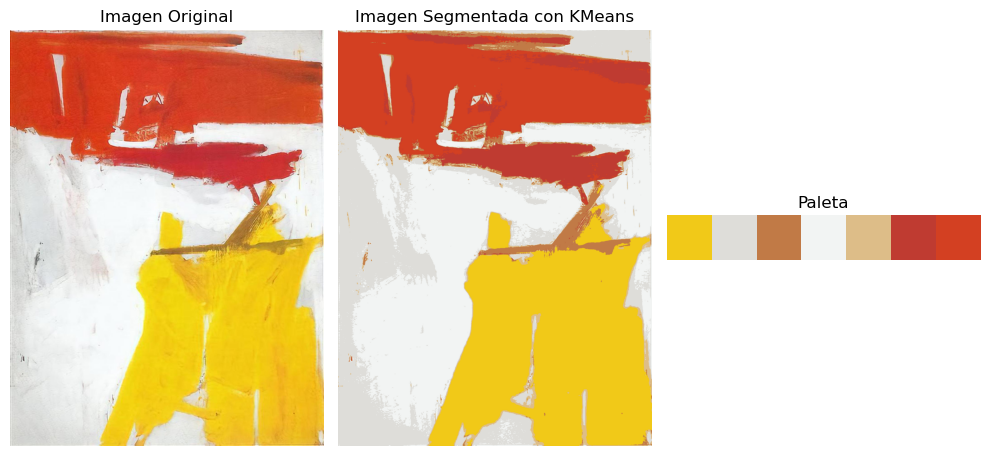

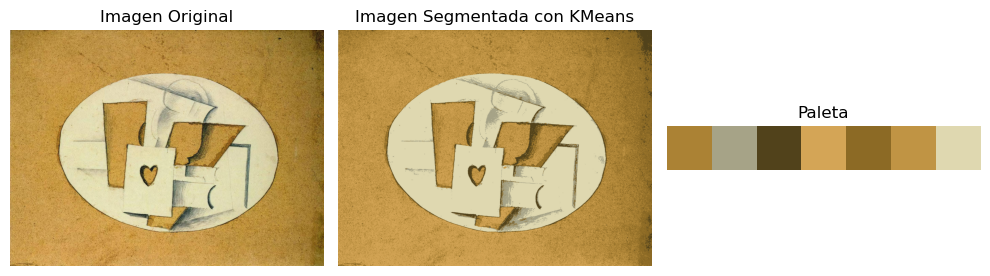

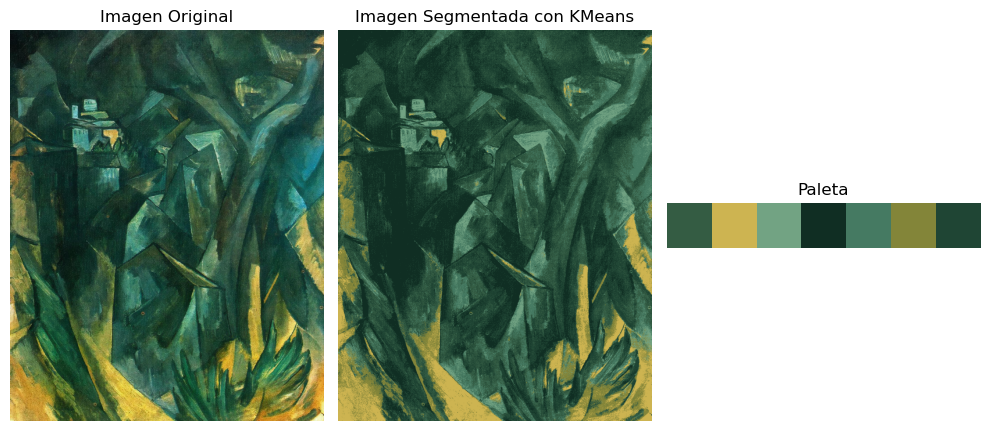

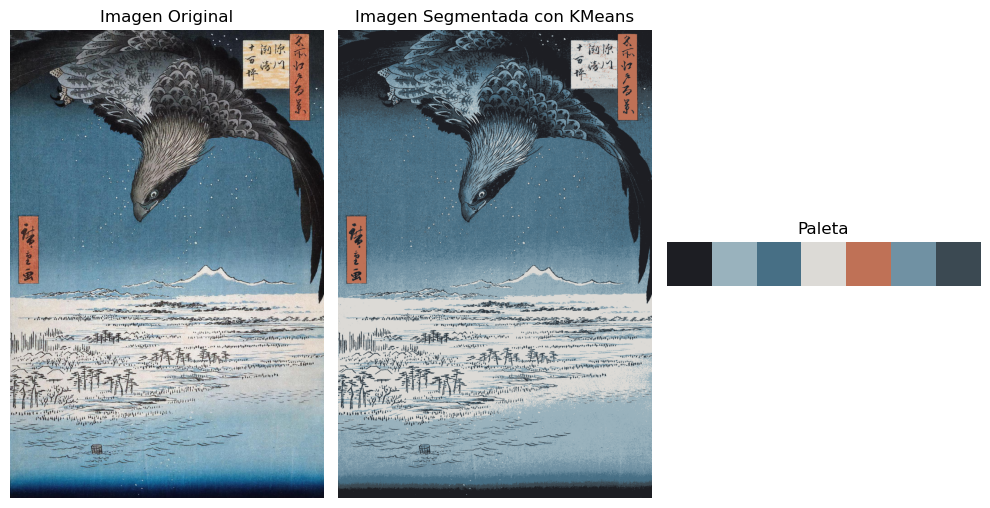

In [ ]:

for img_seg,img_ori,centroi in zip(lista_img_segmented,imagenes_originales,list_centroids):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 3, 1)
    plt.title('Imagen Original')
    plt.imshow(img_ori)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Imagen Segmentada con KMeans')
    plt.imshow(img_seg.astype(np.uint8))
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Paleta')
    plt.imshow(centroi)
    plt.axis('off')

    plt.tight_layout()
    plt.show()